In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path
from collections import Counter

# Load and analyze data

In [2]:
def load(npz_fname):
    data = np.load(fname)
    adc = data['adc']
    sbg = data['sbg']
    return adc, sbg    

In [3]:
def analyze(adc, sbg):
    mask_1 = np.logical_and(adc > 0, sbg == 1)
    mask_0 = np.logical_and(adc > 0, sbg == 0)
    mask_abs = np.logical_and(adc == 0, sbg == 1)

    assert len(adc[mask_abs]) == 0, \
        'signal back ground is positive while adc is zero'
    
    non_signal = adc[mask_0]
    signal = adc[mask_1]
    
    if len(non_signal) == 0:
        non_signal = np.array([-1])
        
    if len(signal) == 0:
        signal = np.array([-1])
    
    return non_signal, signal

# Plot

In [4]:
def process(image, vmax=None):
    X, Y, Z = np.argwhere((image >= 1)).T
    values = image[X, Y, Z]
    if vmax:
        values[values > vmax] = vmax
    return [X, Y, Z], values

def plot_3d(adc, sbg, vmax=None, image_fname=None): 
    positions_adc, values_adc = process(adc, vmax=vmax)
    positions_msk, values_msk = process(adc * sbg, vmax=vmax)

    positions = [positions_adc, positions_msk]
    values = [values_adc, values_msk]
    
    fig = plt.figure(figsize=(10, 5))
    for i, (pos, val) in enumerate(zip(positions, values)):
        ax = fig.add_subplot(121 + i, projection='3d')
        ax.scatter3D(*pos, c=val, s=1, cmap='Blues')
        ax.set_xlim(0, 192)
        ax.set_ylim(0, 249)
        ax.set_zlim(0, 16)
        if i == 0:
            non_signal, signal = analyze(adc, sbg)
            text = f'non signal mean = {non_signal.mean():.2f}, \
                    \nsignal mean = {signal.mean():.2f}\n'
            ax.text2D(0.05, 0.95, text, transform=ax.transAxes)
        
    if image_fname:
        plt.title(Path(image_fname).stem)
        fig.savefig(image_fname, transparent=True, bbox_inches='tight', dpi=200)

# Get frames that has relatively higher occupancy

In [5]:
layer_group = 'middle'
fnames = list(Path(layer_group).rglob('*.npz'))
fnames.sort()

fnames_ho = [] # fnames that has high occupancy data
adc_sum_th = 25000
for fname in fnames:
    adc, sbg = load(fname)
    
    if adc.sum() >= adc_sum_th:
        print(fname, adc.sum())
        fnames_ho.append(fname)
        non_signal, signal = analyze(adc, sbg)
        print(f'non signal mean = {non_signal.mean():.2f}, \
            \nsignal mean = {signal.mean():.2f}\n')

middle/12-2_0-0/TPCMLDataInterface_1.npz 27253
non signal mean = 120.37,             
signal mean = 98.17

middle/12-2_0-0/TPCMLDataInterface_2.npz 26678
non signal mean = 119.25,             
signal mean = 99.03

middle/12-2_0-1/TPCMLDataInterface_9.npz 29161
non signal mean = 101.83,             
signal mean = 98.01

middle/12-2_1-0/TPCMLDataInterface_3.npz 27352
non signal mean = -1.00,             
signal mean = 92.72

middle/12-2_1-0/TPCMLDataInterface_6.npz 33957
non signal mean = 92.40,             
signal mean = 100.34

middle/12-2_1-1/TPCMLDataInterface_2.npz 28840
non signal mean = 93.20,             
signal mean = 98.71

middle/12-2_1-1/TPCMLDataInterface_9.npz 202137
non signal mean = 108.23,             
signal mean = 97.38

middle/12-2_10-1/TPCMLDataInterface_0.npz 59603
non signal mean = 198.54,             
signal mean = 122.09

middle/12-2_10-1/TPCMLDataInterface_6.npz 30681
non signal mean = 98.49,             
signal mean = 97.09

middle/12-2_11-0/TPCMLDataInterface_

# Plot frames with relatively higher occupancy

/tmp/ipykernel_3144903/679337967.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = plt.figure(figsize=(10, 5))


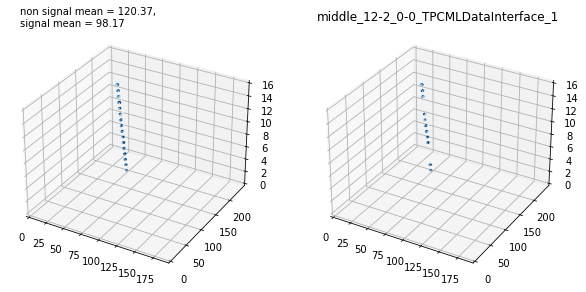

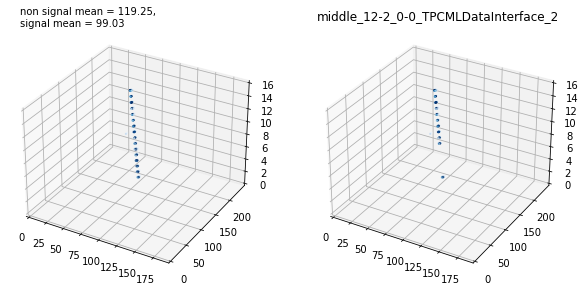

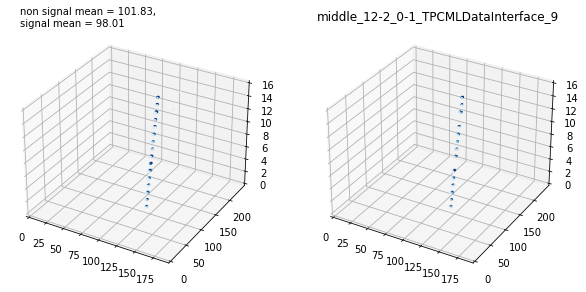

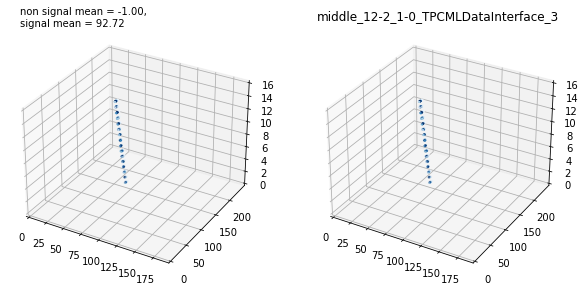

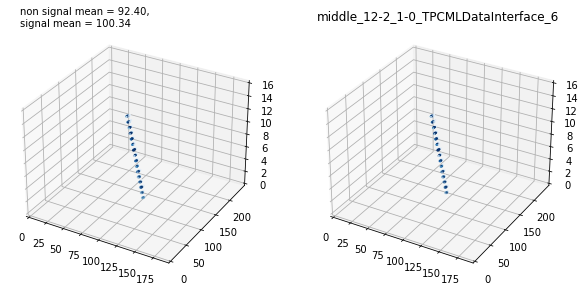

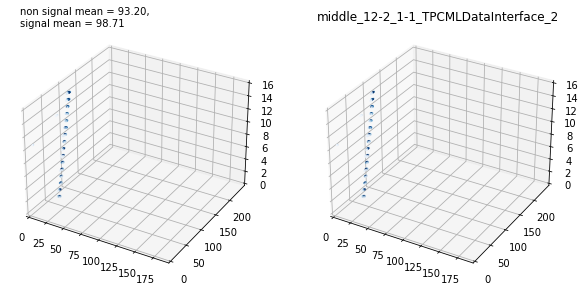

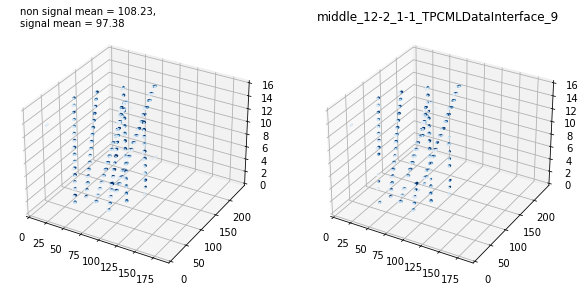

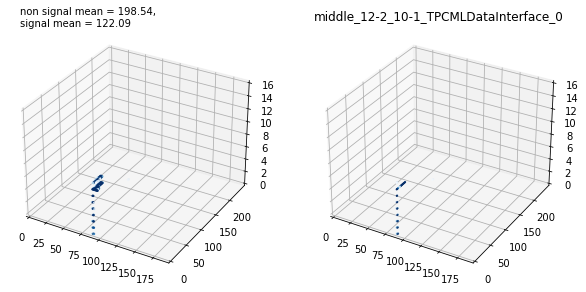

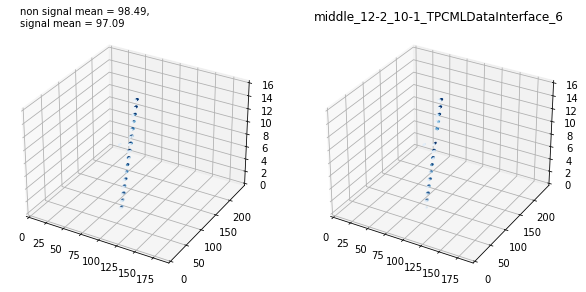

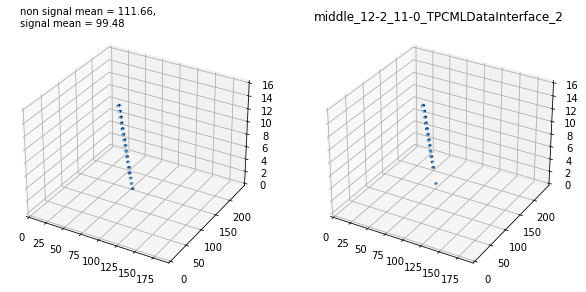

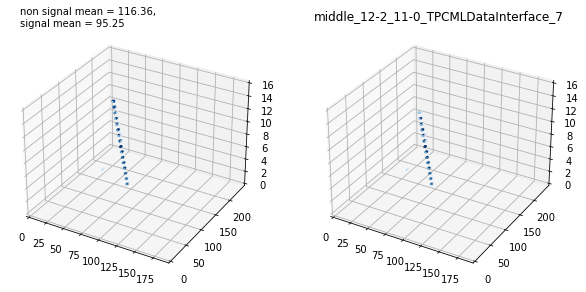

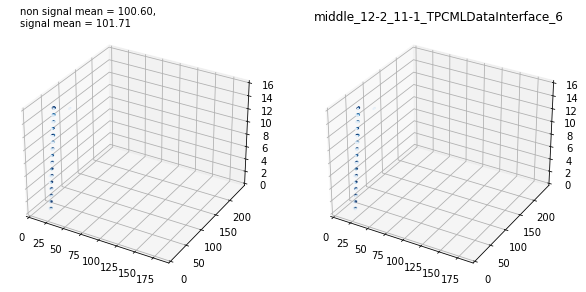

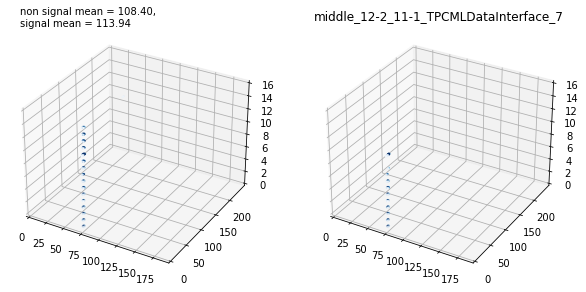

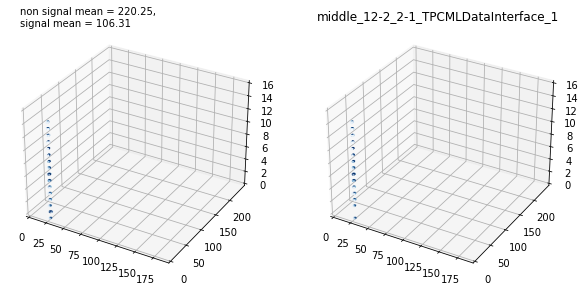

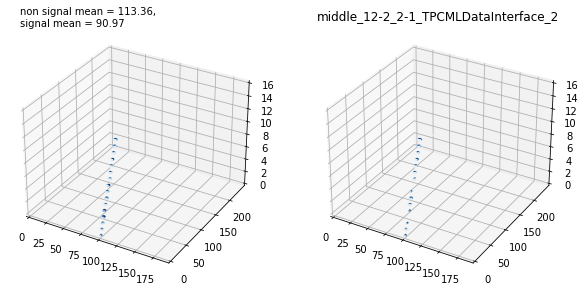

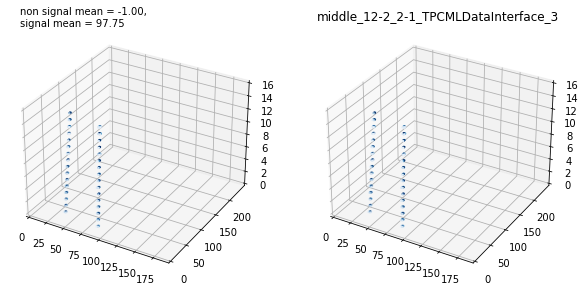

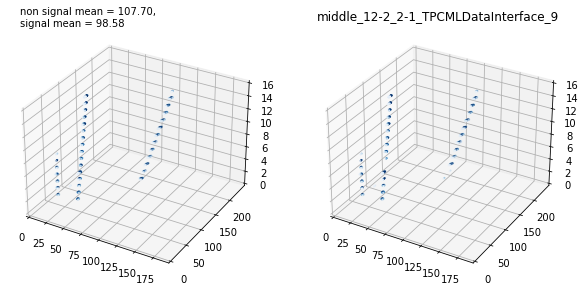

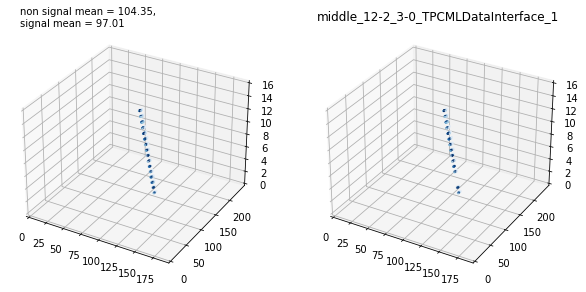

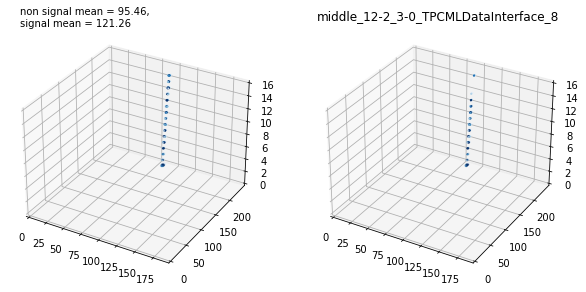

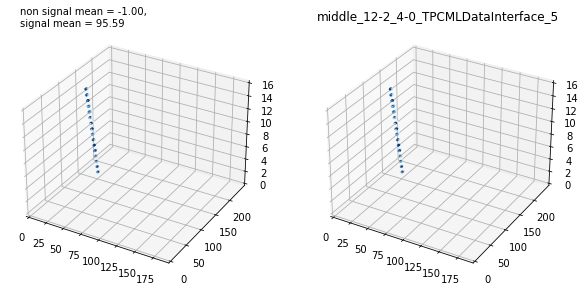

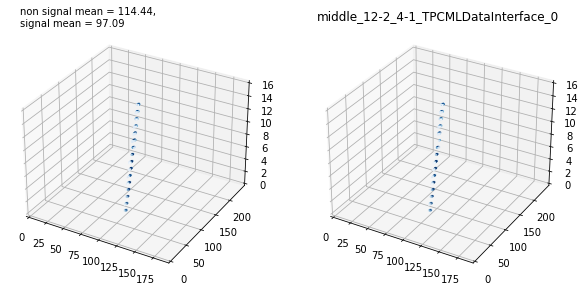

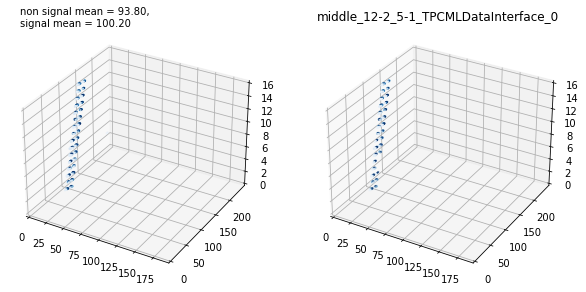

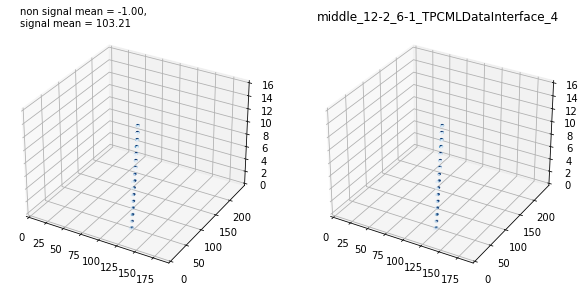

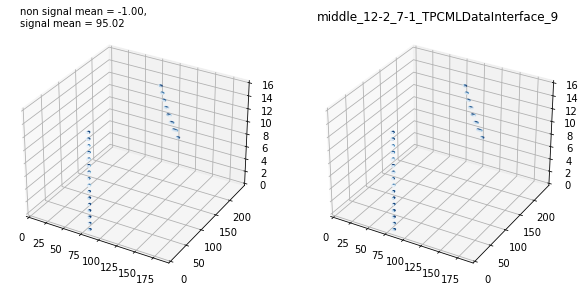

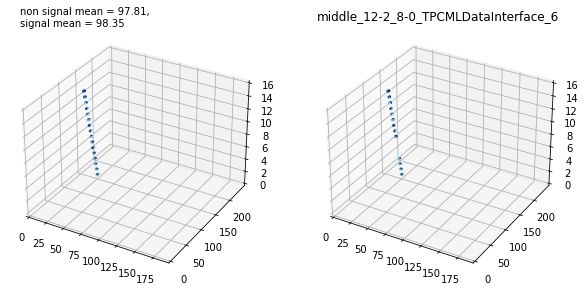

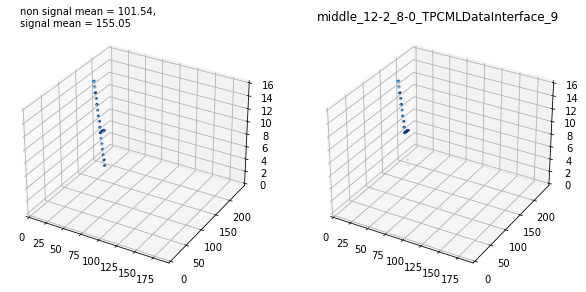

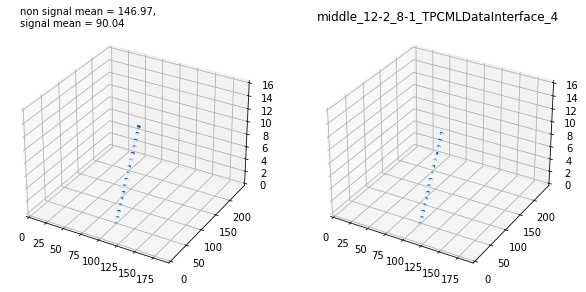

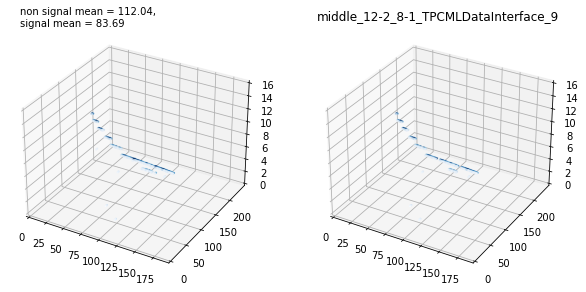

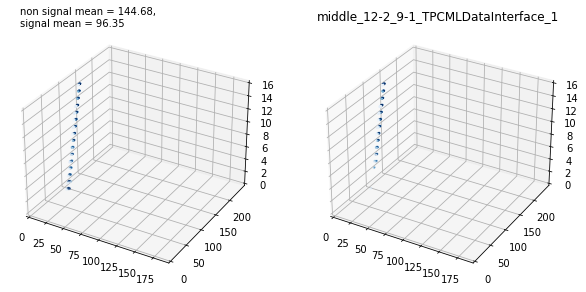

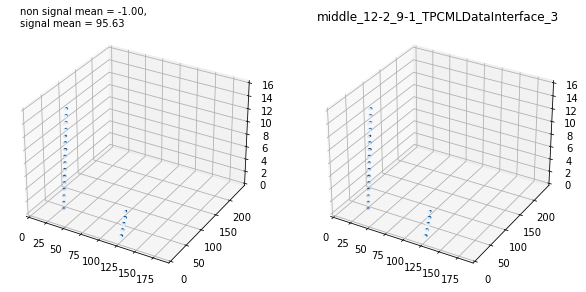

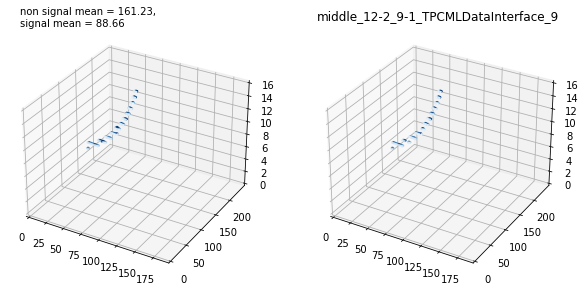

In [6]:
for fname in fnames_ho:
    image_fname = str(fname).replace('/', '_')[:-4] + '.png'
    image_fname = f"images/{image_fname}"
    
    adc, sbg = load(fname)
    plot_3d(adc, sbg, vmax=100, image_fname=image_fname)